Tutorial 3 (CH-4124)

####
Fitting chemical data
From raw numbers to a physical parameter: least squares, nonlinear fits, and log-linearisation.
####

### 1. NumPy warm-up and vectorised chemistry

Build arrays, apply the Beer-Lambert law elementwise, and add measurement noise.

In [35]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Concentration grid (mol/L)
c = np.linspace(0.0, 1.0e-3, 25)

epsilon = 8500.0    # molar absorptivity, L/mol/cm
path_len = 1.0       # cuvette path length, cm

# Beer-Lambert: A = epsilon * l * c
A_true = epsilon * path_len * c

# Add gaussian noise to mimic a real spectrometer
noise = rng.normal(loc=0.0, scale=0.02, size=c.size)
A_obs = A_true + noise

print("shape:", A_obs.shape, "| max A:", A_obs.max().round(3))
print("mean:", A_obs.mean(), "| std:", A_obs.std())

shape: (25,) | max A: 8.518
mean: 4.248531318429831 | std: 2.5551024249288647


### 2. Straight-line least squares

Fit A vs c, recover the molar absorptivity, and judge the fit quality with R-squared.

slope (eps*l): 8503.705194110798
recovered epsilon: 8503.705194110798
intercept: -0.0033212786255688077 | R2: 0.999955384520367


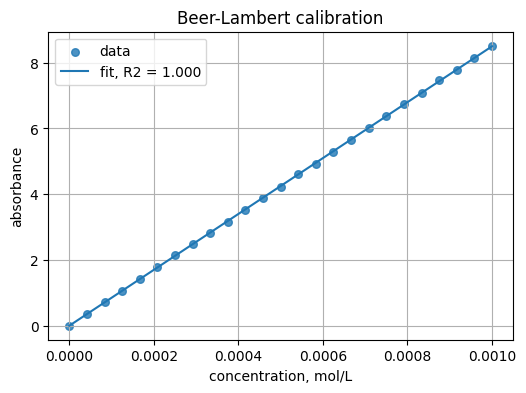

In [36]:
# Fit a first degree polynomial: A = m*c + b
coeffs = np.polyfit(c, A_obs, 1)
m, b = coeffs

A_fit = np.polyval(coeffs, c)

# R-squared
ss_res = np.sum((A_obs - A_fit)**2)
ss_tot = np.sum((A_obs - A_obs.mean())**2)
r2 = 1 - ss_res/ss_tot

print("slope (eps*l):", m)
print("recovered epsilon:", m / path_len)
print("intercept:", b, "| R2:", r2)

plt.figure(figsize=(6, 4))
plt.scatter(c, A_obs, s=30, alpha=0.8, label="data")
plt.plot(c, A_fit, "-", label=f"fit, R2 = {r2:.3f}")
plt.xlabel("concentration, mol/L")
plt.ylabel("absorbance")
plt.title("Beer-Lambert calibration")
plt.legend()
plt.grid(True)

### 3. Residuals

A fit is only as good as its residuals. Plot them and look for structure.

mean residual: 9.44522238199852e-16
RMSE: 0.01706676062576445


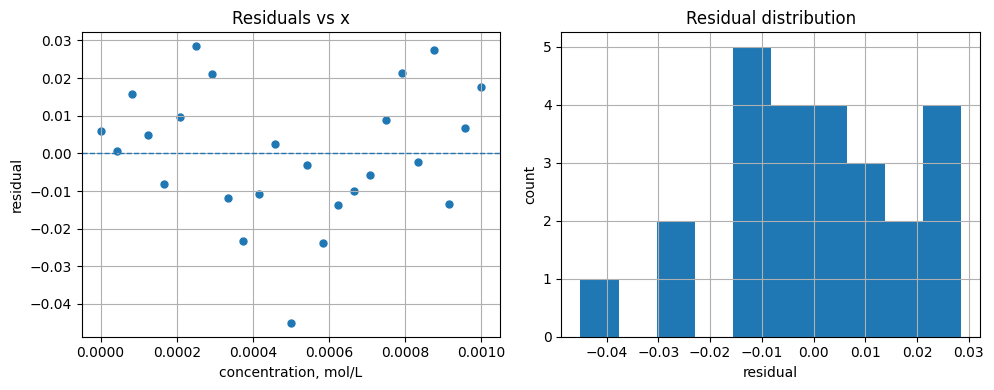

In [37]:
resid = A_obs - A_fit

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(c, resid, s=25)
axes[0].axhline(0.0, ls="--", lw=1)
axes[0].set_xlabel("concentration, mol/L")
axes[0].set_ylabel("residual")
axes[0].set_title("Residuals vs x")
axes[0].grid(True)

axes[1].hist(resid, bins=10)
axes[1].set_xlabel("residual")
axes[1].set_ylabel("count")
axes[1].set_title("Residual distribution")
axes[1].grid(True)

plt.tight_layout()

print("mean residual:", resid.mean())
print("RMSE:", np.sqrt(np.mean(resid**2)))

### 4. Nonlinear fit — first order kinetics

A decays as [A] = [A]0 * exp(-k t). Fit it directly with `curve_fit`, then compare
against the linearised form ln[A] vs t.

A0 = 0.8357 +/- 0.0075
k  = 0.04342 +/- 0.00061 1/min
half life, min: 15.964784364506153


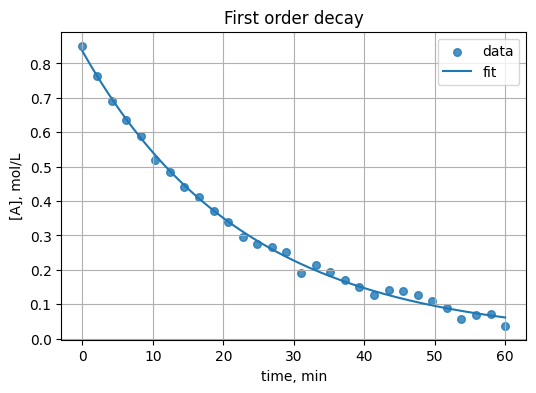

In [38]:
from scipy.optimize import curve_fit

# Synthetic kinetics run
t = np.linspace(0.0, 60.0, 30)          # minutes
A0_true, k_true = 0.85, 0.045
conc = A0_true*np.exp(-k_true*t) + rng.normal(0.0, 0.015, t.size)

def first_order(t, A0, k):
    return A0*np.exp(-k*t)

p0 = [1.0, 0.01]
popt, pcov = curve_fit(first_order, t, conc, p0=p0)

A0_fit, k_fit = popt
perr = np.sqrt(np.diag(pcov))

print(f"A0 = {A0_fit:.4f} +/- {perr[0]:.4f}")
print(f"k  = {k_fit:.5f} +/- {perr[1]:.5f} 1/min")
print("half life, min:", np.log(2)/k_fit)

t_smooth = np.linspace(t.min(), t.max(), 200)

plt.figure(figsize=(6, 4))
plt.scatter(t, conc, s=30, alpha=0.8, label="data")
plt.plot(t_smooth, first_order(t_smooth, *popt), "-", label="fit")
plt.xlabel("time, min")
plt.ylabel("[A], mol/L")
plt.title("First order decay")
plt.legend()
plt.grid(True)

k from linearisation: 0.04469321398830805
k from curve_fit    : 0.043417259183342986


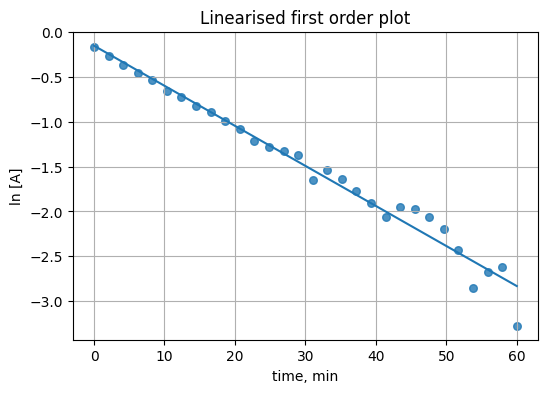

In [39]:
# Linearised check: ln[A] should be straight with slope -k
mask = conc > 0                    # guard against log of a negative noisy point
ln_c = np.log(conc[mask])

slope, intercept = np.polyfit(t[mask], ln_c, 1)
print("k from linearisation:", -slope)
print("k from curve_fit    :", k_fit)

plt.figure(figsize=(6, 4))
plt.scatter(t[mask], ln_c, s=30, alpha=0.8)
plt.plot(t[mask], np.polyval([slope, intercept], t[mask]), "-")
plt.xlabel("time, min")
plt.ylabel("ln [A]")
plt.title("Linearised first order plot")
plt.grid(True)

### 5. New dataset — Arrhenius rate constants

Work with `arrhenius_rates.csv`, columns `run_id`, `temperature_K`, `rate_constant`, `catalyst`.
Tasks:

Read the CSV and inspect it
Add columns for 1/T and ln k
Fit ln k vs 1/T for each catalyst separately
Report Ea in kJ/mol and the pre-exponential factor A
Overlay both fits on one plot

In [40]:
import pandas as pd

path = "/kaggle/input/datasets/sristivats1006/arrhenius/arrhenius_rates.csv"

df = pd.read_csv(path)
print(df.head())
print(df.info())
print(df["catalyst"].value_counts())

# Derived columns
df["inv_T"] = 1.0 / df["temperature_K"]
df["ln_k"]  = np.log(df["rate_constant"])

df.head()

  run_id  temperature_K  rate_constant  catalyst
0   R003            325   5.026310e-04      Pd_C
1   R032            385   2.244798e-04  Ni_Al2O3
2   R004            325   5.064776e-04      Pd_C
3   R022            310   2.763139e-08  Ni_Al2O3
4   R028            355   2.030964e-05  Ni_Al2O3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   run_id         40 non-null     object 
 1   temperature_K  40 non-null     int64  
 2   rate_constant  36 non-null     float64
 3   catalyst       40 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.4+ KB
None
catalyst
Pd_C        20
Ni_Al2O3    20
Name: count, dtype: int64


,run_id,temperature_K,rate_constant,catalyst,inv_T,ln_k
0,R003,325,5.026310e-04,Pd_C,0.003077,-7.595654
1,R032,385,2.244798e-04,Ni_Al2O3,0.002597,-8.401725
2,R004,325,5.064776e-04,Pd_C,0.003077,-7.588030
3,R022,310,2.763139e-08,Ni_Al2O3,0.003226,-17.404313
4,R028,355,2.030964e-05,Ni_Al2O3,0.002817,-10.804415


In [41]:
R = 8.314   # J/mol/K

results = {}

for cat, grp in df.groupby("catalyst"):
    x = grp["inv_T"].to_numpy()
    y = grp["ln_k"].to_numpy()

    slope, intercept = np.polyfit(x, y, 1)

    Ea_kJ = -slope * R / 1000.0
    A_pre = np.exp(intercept)

    results[cat] = {"slope": slope, "intercept": intercept,
                    "Ea_kJ_per_mol": Ea_kJ, "A": A_pre, "n": len(grp)}

    print(f"{cat:>12} | Ea = {Ea_kJ:7.2f} kJ/mol | A = {A_pre:.3e} | n = {len(grp)}")

summary = pd.DataFrame(results).T
summary

    Ni_Al2O3 | Ea =     nan kJ/mol | A = nan | n = 20
        Pd_C | Ea =     nan kJ/mol | A = nan | n = 20


,slope,intercept,Ea_kJ_per_mol,A,n
Ni_Al2O3,NaN,NaN,NaN,NaN,20.0
Pd_C,NaN,NaN,NaN,NaN,20.0


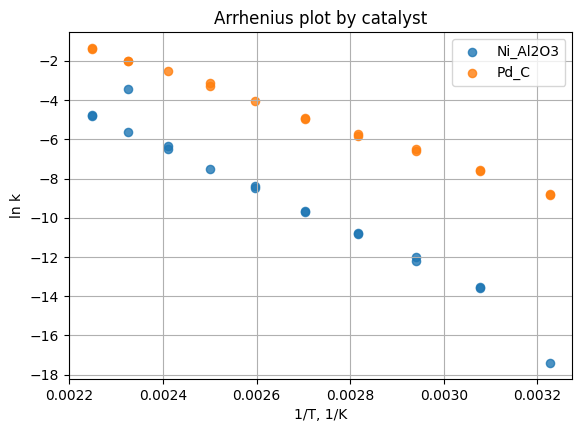

In [42]:
plt.figure(figsize=(6.5, 4.5))

for cat, grp in df.groupby("catalyst"):
    x = grp["inv_T"].to_numpy()
    y = grp["ln_k"].to_numpy()
    plt.scatter(x, y, s=35, alpha=0.8, label=cat)

    fit = results[cat]
    xs = np.linspace(x.min(), x.max(), 50)
    plt.plot(xs, fit["slope"]*xs + fit["intercept"], "--")

plt.xlabel("1/T, 1/K")
plt.ylabel("ln k")
plt.title("Arrhenius plot by catalyst")
plt.legend()
plt.grid(True)

### 6. Messy data

Real files have blanks and outliers. Clean before fitting.

In [43]:
# How many missing values per column?
print(df.isna().sum())

# Drop rows missing the rate constant
df_clean = df.dropna(subset=["rate_constant"]).copy()
print("rows before:", len(df), "| after:", len(df_clean))

# Flag outliers with a z-score on ln k, per catalyst
z = df_clean.groupby("catalyst")["ln_k"].transform(lambda s: (s - s.mean()) / s.std())
df_clean["is_outlier"] = z.abs() > 2.5
print(df_clean["is_outlier"].sum(), "outliers flagged")

df_ok = df_clean[~df_clean["is_outlier"]]

# Refit one catalyst with and without outliers and compare Ea
cat = df_clean["catalyst"].iloc[0]   # pick a catalyst name from the file
sub_all = df_clean[df_clean["catalyst"] == cat]
sub_ok  = df_ok[df_ok["catalyst"] == cat]

for name, sub in [("with outliers", sub_all), ("cleaned", sub_ok)]:
    s, _ = np.polyfit(sub["inv_T"], sub["ln_k"], 1)
    print(f"{name:>14}: Ea = {-s*R/1000:.2f} kJ/mol")

run_id           0
temperature_K    0
rate_constant    4
catalyst         0
inv_T            0
ln_k             4
dtype: int64
rows before: 40 | after: 36
0 outliers flagged
 with outliers: Ea = 62.96 kJ/mol
       cleaned: Ea = 62.96 kJ/mol


### 7. Publication-style figure

Two panels side by side, shared styling, saved to disk at 300 dpi.

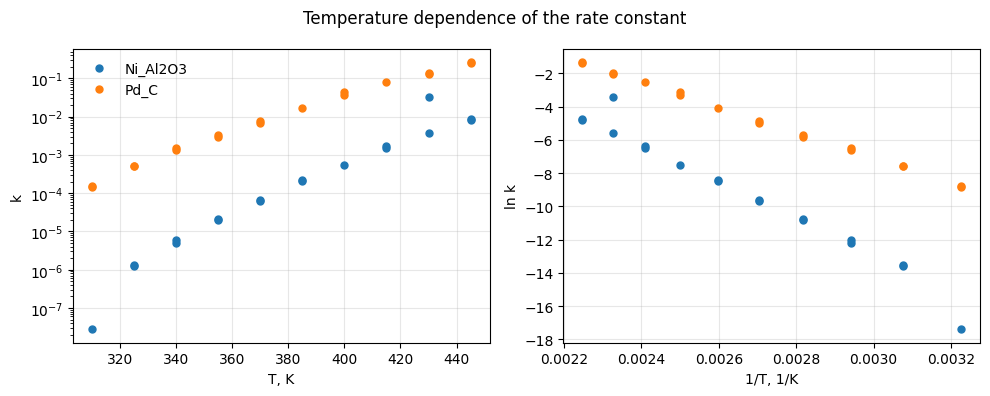

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left: k vs T
for cat, grp in df.groupby("catalyst"):
    ax1.plot(grp["temperature_K"], grp["rate_constant"], "o", ms=5, label=cat)
ax1.set_yscale("log")
ax1.set_xlabel("T, K")
ax1.set_ylabel("k")
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.3)

# Right: Arrhenius
for cat, grp in df.groupby("catalyst"):
    ax2.plot(grp["inv_T"], grp["ln_k"], "o", ms=5, label=cat)
ax2.set_xlabel("1/T, 1/K")
ax2.set_ylabel("ln k")
ax2.grid(True, alpha=0.3)

fig.suptitle("Temperature dependence of the rate constant")
fig.tight_layout()
fig.savefig("arrhenius_figure.png", dpi=300)

### 8. Practice on your own

Repeat the whole pipeline on `enzyme_kinetics.csv` with columns
`substrate_mM`, `velocity_uM_per_min`, `enzyme_batch`.

1. Fit the Michaelis-Menten form v = Vmax*S / (Km + S) with `curve_fit`
2. Report Vmax and Km with their uncertainties for each batch
3. Make a Lineweaver-Burk plot (1/v vs 1/S) and fit it linearly
4. Compare Km from the nonlinear fit against Km from the linearised fit,
   and write one or two sentences on why they disagree

   batch_A | nonlinear: Vmax = 122.017 +/- 1.634, Km = 0.454 +/- 0.027
           | Lineweaver-Burk: Vmax = 122.896, Km = 0.463
   batch_B | nonlinear: Vmax = 94.614 +/- 2.006, Km = 1.136 +/- 0.083
           | Lineweaver-Burk: Vmax = 57.833, Km = 0.443
   batch_C | nonlinear: Vmax = 137.622 +/- 2.212, Km = 0.606 +/- 0.040
           | Lineweaver-Burk: Vmax = 193.770, Km = 1.107


,Vmax_nl,Vmax_nl_err,Km_nl,Km_nl_err,Vmax_lb,Km_lb
batch_A,122.017322,1.633811,0.454174,0.027077,122.895902,0.463106
batch_B,94.613838,2.006320,1.136456,0.083131,57.832673,0.442911
batch_C,137.621974,2.212347,0.606007,0.040102,193.769943,1.106502


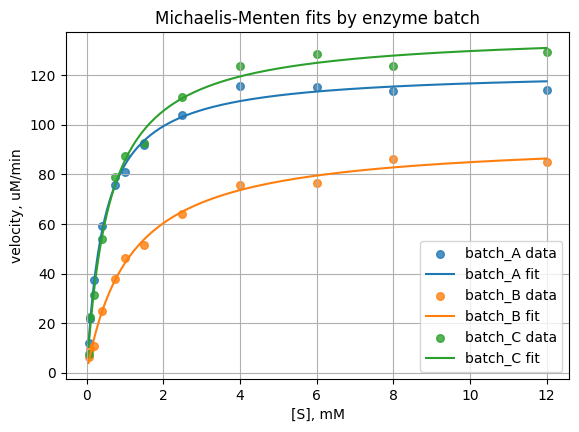

In [45]:
def michaelis_menten(S, Vmax, Km):
    return Vmax * S / (Km + S)

# 1) Read the data
df_e = pd.read_csv("/kaggle/input/datasets/sristivats1006/enzyme/enzyme_kinetics.csv")

results_mm = {}

plt.figure(figsize=(6.5, 4.5))

# 2) Loop over enzyme batches, fit Michaelis-Menten with curve_fit
for batch, grp in df_e.groupby("enzyme_batch"):
    S = grp["substrate_mM"].to_numpy()
    v = grp["velocity_uM_per_min"].to_numpy()

    p0 = [v.max(), np.median(S)]
    popt, pcov = curve_fit(michaelis_menten, S, v, p0=p0)
    Vmax_fit, Km_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # 3) Lineweaver-Burk: 1/v vs 1/S, fit linearly
    inv_S = 1.0 / S
    inv_v = 1.0 / v
    slope, intercept = np.polyfit(inv_S, inv_v, 1)
    Km_lb = slope / intercept
    Vmax_lb = 1.0 / intercept

    results_mm[batch] = {
        "Vmax_nl": Vmax_fit, "Vmax_nl_err": perr[0],
        "Km_nl": Km_fit, "Km_nl_err": perr[1],
        "Vmax_lb": Vmax_lb, "Km_lb": Km_lb,
    }

    print(f"{batch:>10} | nonlinear: Vmax = {Vmax_fit:.3f} +/- {perr[0]:.3f}, "
          f"Km = {Km_fit:.3f} +/- {perr[1]:.3f}")
    print(f"{'':>10} | Lineweaver-Burk: Vmax = {Vmax_lb:.3f}, Km = {Km_lb:.3f}")

    S_smooth = np.linspace(S.min(), S.max(), 200)
    plt.scatter(S, v, s=30, alpha=0.8, label=f"{batch} data")
    plt.plot(S_smooth, michaelis_menten(S_smooth, *popt), "-", label=f"{batch} fit")

plt.xlabel("[S], mM")
plt.ylabel("velocity, uM/min")
plt.title("Michaelis-Menten fits by enzyme batch")
plt.legend()
plt.grid(True)

summary_mm = pd.DataFrame(results_mm).T
summary_mm
